In [1]:
import torch.nn as nn
import pandas as pd 
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
# from google.colab import runtime
# runtime.unassign()
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    print("Colab drive not available; using local paths if present.")
%pip install extinction==0.4.7

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 582.9/582.9 kB 25.2 MB/s eta 0:00:00


In [8]:

root_candidates = [
    Path.cwd() / "data" / "mallorn-astronomical-classification-challenge",
    Path("/content/drive/MyDrive/data/mallorn-astronomical-classification-challenge/"),
    Path("c:/Users/mlady/Documents/202620/stat6685/finalproject/data/mallorn-astronomical-classification-challenge"),
]
root = next((path for path in root_candidates if path.exists()), root_candidates[0])
# 1) Global training metadata with labels
train_log = pd.read_csv(root / "train_log.csv")
test_log = pd.read_csv(root / "test_log.csv")

# 2) Load one split's lightcurves and attach labels/features from global log
def load_split(split_name: str, is_test=False):
    if is_test:
        lc_path = root / split_name / "test_full_lightcurves.csv"
    else:
        lc_path = root / split_name / "train_full_lightcurves.csv"
    lc = pd.read_csv(lc_path)

    log = test_log if is_test else train_log

    # Keep only metadata rows for this split
    meta = log.loc[log["split"] == split_name].copy()

    # Merge target + static features onto each observation row
    merge_cols = ["object_id", "Z", "Z_err", "EBV", "SpecType", "split"]
    if not is_test and "target" in meta.columns:
        merge_cols.insert(1, "target")
    merge_cols = [col for col in merge_cols if col in meta.columns]
    merged = lc.merge(
        meta[merge_cols],
        on="object_id",
        how="left",
        validate="many_to_one"
    )

    # Flux in CSV is extincted; derive de-extincted flux using per-row EBV + filter.
    if "apply_mw_deextinction" in globals():
        merged = globals()["apply_mw_deextinction"](merged)
    else:
        merged = merged.copy()
        merged["Flux_deext"] = pd.to_numeric(merged["Flux"], errors="coerce")
        merged["Flux_err_deext"] = pd.to_numeric(merged["Flux_err"], errors="coerce")
        merged["A_lambda"] = 0.0

    return merged, meta

In [9]:
from extinction import fitzpatrick99

R_V = 3.1  # Standard Milky Way value
EFFECTIVE_WAVELENGTHS = {
    "u": 3641.0,
    "g": 4704.0,
    "r": 6155.0,
    "i": 7504.0,
    "z": 8695.0,
    "y": 10056.0,
}

# Precompute A_lambda / E(B-V) for each LSST band.
A_LAMBDA_PER_EBV = {
    f: float(fitzpatrick99(np.array([wl], dtype=np.float64), 1.0 * R_V)[0])
    for f, wl in EFFECTIVE_WAVELENGTHS.items()
}

def jurassic_park(flux, eff_wl, ebv):
    a_lambda = fitzpatrick99(np.asarray(eff_wl, dtype=np.float64), float(ebv) * R_V)
    flux_deext = np.asarray(flux, dtype=np.float64) * np.power(10.0, a_lambda / 2.5)
    return flux_deext, a_lambda

def apply_mw_deextinction(df):
    corrected = df.copy()

    ebv = pd.to_numeric(corrected.get("EBV", 0.0), errors="coerce").fillna(0.0).to_numpy(dtype=np.float64)
    filt = corrected["Filter"].astype(str).to_numpy()
    k_lambda = np.array([A_LAMBDA_PER_EBV.get(f, 0.0) for f in filt], dtype=np.float64)

    a_lambda = ebv * k_lambda
    scale = np.power(10.0, a_lambda / 2.5)

    flux = pd.to_numeric(corrected["Flux"], errors="coerce").to_numpy(dtype=np.float64)
    flux_err = pd.to_numeric(corrected["Flux_err"], errors="coerce").to_numpy(dtype=np.float64)

    corrected["Flux_deext"] = flux * scale
    corrected["Flux_err_deext"] = flux_err * scale
    corrected["A_lambda"] = a_lambda
    return corrected

In [10]:
FILTER_ORDER = ["u", "g", "r", "i", "z", "y"]
FILTER_TO_IDX = {f: i for i, f in enumerate(FILTER_ORDER)}

def encode_sequence(obj_df):
    obj_df = obj_df.sort_values("Time (MJD)").copy()

    # Prefer de-extincted columns when available.
    flux_col = "Flux_deext" if "Flux_deext" in obj_df.columns else "Flux"
    flux_err_col = "Flux_err_deext" if "Flux_err_deext" in obj_df.columns else "Flux_err"

    # Robust numeric conversion + NaN handling to prevent NaN loss during training
    t = pd.to_numeric(obj_df["Time (MJD)"], errors="coerce").to_numpy(dtype=np.float32)
    flux = pd.to_numeric(obj_df[flux_col], errors="coerce").to_numpy(dtype=np.float32)
    flux_err = pd.to_numeric(obj_df[flux_err_col], errors="coerce").to_numpy(dtype=np.float32)

    t = np.nan_to_num(t, nan=0.0, posinf=0.0, neginf=0.0)
    flux = np.nan_to_num(flux, nan=0.0, posinf=0.0, neginf=0.0)
    flux_err = np.nan_to_num(flux_err, nan=0.0, posinf=0.0, neginf=0.0)

    dt = np.diff(t, prepend=t[0]).astype(np.float32)
    dt = np.clip(dt, a_min=0.0, a_max=1e4)

    # Stabilize dynamic ranges for RNN training
    flux = np.clip(flux, -1e5, 1e5)
    flux_err = np.clip(flux_err, 0.0, 1e5)

    filt_oh = np.zeros((len(obj_df), len(FILTER_ORDER)), dtype=np.float32)
    filt_idx = obj_df["Filter"].map(FILTER_TO_IDX).to_numpy()
    valid = ~pd.isna(filt_idx)
    filt_oh[np.arange(len(obj_df))[valid], filt_idx[valid].astype(int)] = 1.0

    x = np.column_stack([flux, flux_err, dt, filt_oh]).astype(np.float32)
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    return torch.tensor(x, dtype=torch.float32)

class LightCurveSplitDataset(Dataset):
    def __init__(self, split_name, root_path, is_test=False):
        self.split_name = split_name
        self.root_path = root_path
        self.is_test = is_test

        self.merged, self.meta = load_split(split_name, is_test=is_test)

        self.meta = self.meta.set_index("object_id", drop=False)

        object_set = set(self.merged["object_id"].unique())
        self.object_ids = [oid for oid in self.meta["object_id"].tolist() if oid in object_set]
        self.grouped = dict(tuple(self.merged.groupby("object_id")))

    def __len__(self):
        return len(self.object_ids)

    def __getitem__(self, idx):
        oid = self.object_ids[idx]
        obj_df = self.grouped[oid]
        m = self.meta.loc[oid]

        seq = encode_sequence(obj_df)

        z = 0.0 if pd.isna(m.get("Z", np.nan)) else float(m["Z"] )
        z_err = 0.0 if pd.isna(m.get("Z_err", np.nan)) else float(m["Z_err"] )
        ebv = 0.0 if pd.isna(m.get("EBV", np.nan)) else float(m["EBV"] )
        static_np = np.array([z, z_err, ebv], dtype=np.float32)
        static_np = np.nan_to_num(static_np, nan=0.0, posinf=0.0, neginf=0.0)
        static_np = np.clip(static_np, -1e3, 1e3)
        static = torch.tensor(static_np, dtype=torch.float32)

        sample = {
            "object_id": oid,
            "seq": seq,
            "static": static,
        }

        if not self.is_test and "target" in self.merged.columns:
            sample["y"] = torch.tensor(float(m["target"]), dtype=torch.float32)

        return sample

"""
Build one mini-batch from a list of dataset samples.
"""
def collate_pad(batch):
    seqs = [b["seq"] for b in batch]
    lengths = torch.tensor([s.size(0) for s in seqs], dtype=torch.long)
    seq_padded = pad_sequence(seqs, batch_first=True)

    static = torch.stack([b["static"] for b in batch], dim=0)
    y = torch.stack([b["y"] for b in batch], dim=0)
    obj_ids = [b["object_id"] for b in batch]

    return {
        "object_id": obj_ids,
        "seq": seq_padded,
        "lengths": lengths,
        "static": static,
        "y": y
    }

def collate_pad_test(batch):
    seqs = [b["seq"] for b in batch]
    lengths = torch.tensor([s.size(0) for s in seqs], dtype=torch.long)
    seq_padded = pad_sequence(seqs, batch_first=True)

    static = torch.stack([b["static"] for b in batch], dim=0)
    obj_ids = [b["object_id"] for b in batch]

    return {
        "object_id": obj_ids,
        "seq": seq_padded,
        "lengths": lengths,
        "static": static,
    }

# Example usage:
train_ds = LightCurveSplitDataset("split_01", root)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, collate_fn=collate_pad)

batch = next(iter(train_loader))

In [11]:
# Optional utility: de-extinct per-band flux values for a single EBV value
def deextinct_by_band(flux_by_band, ebv):
    out_flux = {}
    out_a_lambda = {}
    for band, flux in flux_by_band.items():
        eff_wl = np.array([EFFECTIVE_WAVELENGTHS[band]], dtype=np.float64)
        out_flux[band], out_a_lambda[band] = jurassic_park(flux, eff_wl, ebv)
    return out_flux, out_a_lambda

In [17]:
class LSTMWithStatic(nn.Module):
    def __init__(self, seq_input_size=9, static_input_size=3, hidden_size=64, num_layers=1, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=seq_input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.static_net = nn.Sequential(
            nn.Linear(static_input_size, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size + 16, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, seq, lengths, static):
        packed = nn.utils.rnn.pack_padded_sequence(
            seq, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, (h_n, _) = self.lstm(packed)
        seq_repr = h_n[-1]
        static_repr = self.static_net(static)
        x = torch.cat([seq_repr, static_repr], dim=1)
        logits = self.head(x).squeeze(1)
        return logits
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMWithStatic(seq_input_size=9, static_input_size=3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

In [ ]:




all_splits = sorted(train_log["split"].dropna().unique().tolist())
val_splits = [all_splits[-1]]  # hold out last split for validation
train_splits = [s for s in all_splits if s not in val_splits]

print("Train splits:", train_splits)
print("Val splits:", val_splits)

# Build loaders
train_loaders = {}
val_loaders = {}
all_targets = []

for split_name in train_splits:
    ds = LightCurveSplitDataset(split_name, root)
    train_loaders[split_name] = DataLoader(ds, batch_size=64, shuffle=True, collate_fn=collate_pad)
    all_targets.append(ds.meta["target"].astype(float).values)

for split_name in val_splits:
    ds = LightCurveSplitDataset(split_name, root)
    val_loaders[split_name] = DataLoader(ds, batch_size=128, shuffle=False, collate_fn=collate_pad)

all_targets = np.concatenate(all_targets)
pos = float((all_targets == 1).sum())
neg = float((all_targets == 0).sum())
pos_weight = torch.tensor([neg / max(pos, 1.0)], dtype=torch.float32, device=device)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
print(f"Class balance (train only) -> pos: {int(pos)}, neg: {int(neg)}, pos_weight: {pos_weight.item():.2f}")

def eval_on_loaders(loaders, threshold=0.5):
    model.eval()
    logits_all = []
    y_all = []
    with torch.no_grad():
        for split_name in loaders:
            for batch in loaders[split_name]:
                seq = batch["seq"].to(device)
                lengths = batch["lengths"]
                static = batch["static"].to(device)
                y = batch["y"].to(device)

                logits = model(seq, lengths, static)
                logits = torch.nan_to_num(logits, nan=0.0, posinf=0.0, neginf=0.0)
                logits_all.append(logits.cpu())
                y_all.append(y.cpu())

    logits_all = torch.cat(logits_all)
    y_all = torch.cat(y_all)
    probs = torch.sigmoid(logits_all)
    preds = (probs >= threshold).float()

    acc = (preds == y_all).float().mean().item()
    precision = ((preds * y_all).sum() / (preds.sum() + 1e-8)).item()
    recall = ((preds * y_all).sum() / (y_all.sum() + 1e-8)).item()
    f1 = (2 * precision * recall) / (precision + recall + 1e-8)
    return {
        "acc": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "probs": probs,
        "y": y_all,
    }

def tune_threshold(probs, y_true):
    best_thr = 0.5
    best_f1 = -1.0
    for thr in np.arange(0.05, 0.96, 0.01):
        preds = (probs >= thr).float()
        precision = ((preds * y_true).sum() / (preds.sum() + 1e-8)).item()
        recall = ((preds * y_true).sum() / (y_true.sum() + 1e-8)).item()
        f1 = (2 * precision * recall) / (precision + recall + 1e-8)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = float(thr)
    return best_thr, best_f1

n_epochs = 100
patience = 12
epochs_without_improve = 0
best_val_f1 = -1.0
best_threshold = 0.5
best_state_dict = None

# Track metrics for plotting F1 over epochs
epoch_history = []
train_f1_history = []
val_f1_05_history = []
val_f1_tuned_history = []
threshold_history = []

for epoch in range(1, n_epochs + 1):
    model.train()
    running_loss = 0.0
    n_obs = 0

    for split_name in train_splits:
        loader = train_loaders[split_name]
        for batch in loader:
            seq = batch["seq"].to(device)
            lengths = batch["lengths"]
            static = batch["static"].to(device)
            y = batch["y"].to(device)

            logits = model(seq, lengths, static)
            loss = loss_fn(logits, y)

            if torch.isnan(loss):
                print(f"NaN loss detected in {split_name}. Skipping this batch.")
                continue

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            bs = y.size(0)
            running_loss += loss.item() * bs
            n_obs += bs

    epoch_loss = running_loss / max(n_obs, 1)

    if epoch == 1 or epoch % 2 == 0:
        train_metrics = eval_on_loaders(train_loaders, threshold=0.5)
        val_metrics_05 = eval_on_loaders(val_loaders, threshold=0.5)
        tuned_thr, tuned_val_f1 = tune_threshold(val_metrics_05["probs"], val_metrics_05["y"] )
        val_metrics_tuned = eval_on_loaders(val_loaders, threshold=tuned_thr)

        epoch_history.append(epoch)
        train_f1_history.append(train_metrics["f1"] )
        val_f1_05_history.append(val_metrics_05["f1"] )
        val_f1_tuned_history.append(val_metrics_tuned["f1"] )
        threshold_history.append(tuned_thr)

        print(
            f"Epoch {epoch:02d} | loss={epoch_loss:.4f} | "
            f"train_f1@0.50={train_metrics['f1']:.4f} | "
            f"val_f1@0.50={val_metrics_05['f1']:.4f} | "
            f"val_f1@{tuned_thr:.2f}={val_metrics_tuned['f1']:.4f}"
        )

        if val_metrics_tuned["f1"] > best_val_f1 + 1e-6:
            best_val_f1 = val_metrics_tuned["f1"]
            best_threshold = tuned_thr
            best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improve = 0
        else:
            epochs_without_improve += 1

        if epochs_without_improve >= patience:
            print(f"Early stopping at epoch {epoch} (best val_f1={best_val_f1:.4f}, best_threshold={best_threshold:.2f})")
            break

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    print(f"Loaded best checkpoint with val_f1={best_val_f1:.4f} at threshold={best_threshold:.2f}")
else:
    best_threshold = 0.5
    print("No validation improvement tracked; using threshold=0.5")

Train splits: ['split_01', 'split_02', 'split_03', 'split_04', 'split_05', 'split_06', 'split_07', 'split_08', 'split_09', 'split_10', 'split_11', 'split_12', 'split_13', 'split_14', 'split_15', 'split_16', 'split_17', 'split_18', 'split_19']
Val splits: ['split_20']


KeyboardInterrupt: 

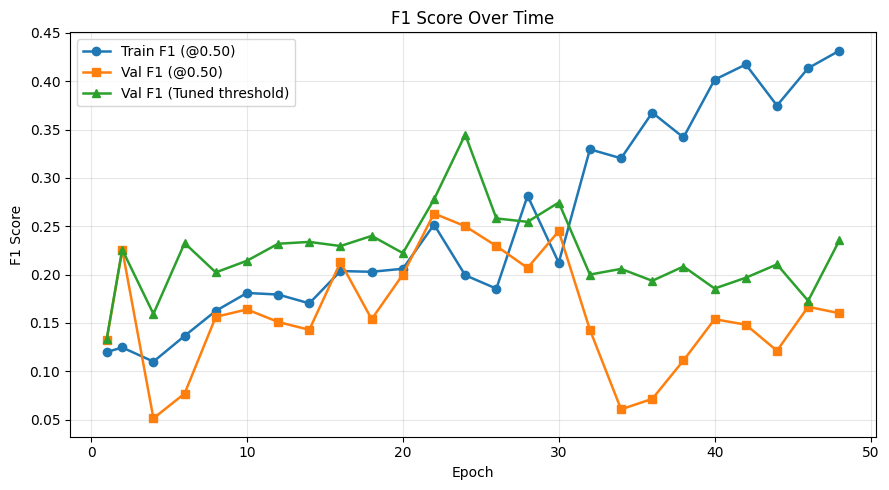

In [10]:
import matplotlib.pyplot as plt

# Plot F1 score over training epochs (evaluation checkpoints)
if len(epoch_history) == 0:
    raise ValueError("No metric history found. Run the training cell first.")

plt.figure(figsize=(9, 5))
plt.plot(epoch_history, train_f1_history, marker="o", linewidth=1.8, label="Train F1 (@0.50)")
plt.plot(epoch_history, val_f1_05_history, marker="s", linewidth=1.8, label="Val F1 (@0.50)")
plt.plot(epoch_history, val_f1_tuned_history, marker="^", linewidth=1.8, label="Val F1 (Tuned threshold)")

plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("F1 Score Over Time")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# Save trained model (and training state) to Google Drive
ckpt_dir = root / "checkpoints"
ckpt_dir.mkdir(parents=True, exist_ok=True)

# Resolve missing references safely
eval_threshold = float(best_threshold) if "best_threshold" in globals() else 0.5

if "val_loaders" in globals() and len(val_loaders) > 0:
    metrics = eval_on_loaders(val_loaders, threshold=eval_threshold)
elif "train_loaders" in globals() and len(train_loaders) > 0:
    metrics = eval_on_loaders(train_loaders, threshold=eval_threshold)
else:
    metrics = {"acc": None, "precision": None, "recall": None, "f1": None}

ckpt_path = ckpt_dir / "lstm_with_static_split01_20_apr17_2.pt"
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "epoch": int(epoch) if "epoch" in globals() else None,
        "loss": float(epoch_loss) if "epoch_loss" in globals() else None,
        "acc": metrics["acc"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],
        "best_val_f1": float(best_val_f1) if "best_val_f1" in globals() else None,
        "best_threshold": eval_threshold,
        "pos_weight": pos_weight.detach().cpu() if "pos_weight" in globals() else None,
        "split_names": {
            "train_splits": train_splits if "train_splits" in globals() else [],
            "val_splits": val_splits if "val_splits" in globals() else [],
        },
    },
    ckpt_path,
)

print(f"Saved checkpoint to: {ckpt_path}")



NameError: name 'eval_on_loaders' is not defined

In [20]:

def load_model(model, ckpt_path):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    checkpoint = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    print(f"Loaded checkpoint from: {ckpt_path}")

root = Path("/content/drive/MyDrive/data/mallorn-astronomical-classification-challenge/")
ckpt_dir = root / Path("checkpoints")
ckpt_dir.mkdir(parents=True, exist_ok=True)
ckpt_path = ckpt_dir / Path("lstm_with_static_split01_20_apr17_2.pt")
load_model(model, ckpt_path)
test_split_names = sorted(test_log["split"].dropna().unique().tolist())
pred_rows = []
batch_size = 128
inference_threshold = float(best_threshold) if "best_threshold" in globals() else 0.5
print(f"Using inference threshold: {inference_threshold:.2f}")

with torch.no_grad():
    for split_name in test_split_names:
        lc = pd.read_csv(root / split_name / "test_full_lightcurves.csv")
        meta = test_log.loc[test_log["split"] == split_name].copy().set_index("object_id", drop=False)

        # Attach EBV so test flux can be de-extincted consistently.
        lc = lc.merge(
            meta[["object_id", "EBV"]].reset_index(drop=True),
            on="object_id",
            how="left",
            validate="many_to_one",
        )
        lc = apply_mw_deextinction(lc)

        grouped = dict(tuple(lc.groupby("object_id")))
        object_ids = [oid for oid in meta["object_id"].tolist() if oid in grouped]

        for start in range(0, len(object_ids), batch_size):
            batch_ids = object_ids[start:start + batch_size]
            seqs = []
            statics = []

            for object_id in batch_ids:
                obj_df = grouped[object_id]
                seqs.append(encode_sequence(obj_df))

                m = meta.loc[object_id]
                z = 0.0 if pd.isna(m.get("Z", np.nan)) else float(m["Z"])
                z_err = 0.0 if pd.isna(m.get("Z_err", np.nan)) else float(m["Z_err"])
                ebv = 0.0 if pd.isna(m.get("EBV", np.nan)) else float(m["EBV"])
                static_np = np.array([z, z_err, ebv], dtype=np.float32)
                static_np = np.nan_to_num(static_np, nan=0.0, posinf=0.0, neginf=0.0)
                statics.append(torch.tensor(np.clip(static_np, -1e3, 1e3), dtype=torch.float32))

            lengths = torch.tensor([seq.size(0) for seq in seqs], dtype=torch.long)
            seq_padded = pad_sequence(seqs, batch_first=True)
            static = torch.stack(statics, dim=0)

            logits = model(seq_padded.to(device), lengths, static.to(device))
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs >= inference_threshold).astype(int)
            confidences = np.where(preds == 1, probs, 1.0 - probs)

            for object_id, pred, prob, conf in zip(batch_ids, preds, probs, confidences):
                pred_rows.append(
                    {
                        "object_id": object_id,
                        "prediction": int(pred),
                        "tde_probability": float(prob),
                        "confidence": float(conf),
                    }
                )

pred_df = pd.DataFrame(pred_rows)
sample_submission = pd.read_csv(root / "sample_submission.csv")
pred_df = sample_submission[["object_id"]].merge(pred_df, on="object_id", how="left")
pred_df["prediction"] = pred_df["prediction"].fillna(0).astype(int)
pred_df["tde_probability"] = pred_df["tde_probability"].fillna(0.0).astype(float)
pred_df["confidence"] = pred_df["confidence"].fillna(0.5).astype(float)

output_path = root / "submission.csv"
pred_df.to_csv(output_path, index=False)
print(f"Saved predictions to: {output_path}")
print(pred_df.head(12).to_csv(index=False).strip())
# Save predictions as probability CSV with only object_id and probability columns
prob_csv_path = root / "lstm_probability.csv"
prob_df = pd.DataFrame({
    "object_id": pred_df["object_id"],
    "probability": pred_df["tde_probability"]
})
prob_df.to_csv(prob_csv_path, index=False)
print(f"Saved probability predictions to: {prob_csv_path}")
print(prob_df.head(10))

Loaded checkpoint from: /content/drive/MyDrive/data/mallorn-astronomical-classification-challenge/checkpoints/lstm_with_static_split01_20_apr17_2.pt
Using inference threshold: 0.50
Saved predictions to: /content/drive/MyDrive/data/mallorn-astronomical-classification-challenge/submission.csv
object_id,prediction,tde_probability,confidence
Eluwaith_Mithrim_nothrim,0,0.04089997336268425,0.9591000080108643
Eru_heledir_archam,0,0.31104108691215515,0.6889588832855225
Gonhir_anann_fuin,0,0.24269193410873413,0.7573080658912659
Gwathuirim_haradrim_tegilbor,1,0.6820307374000549,0.6820307374000549
achas_minai_maen,1,0.8011156916618347,0.8011156916618347
adab_fae_gath,1,0.5270315408706665,0.5270315408706665
adel_draug_gaur,0,0.4386345148086548,0.5613654851913452
aderthad_cuil_galadhrim,0,0.4762214124202728,0.5237785577774048
aegas_laug_ithildin,0,0.2883155047893524,0.7116844654083252
aegas_mereth_law,0,0.4495345652103424,0.55046546459198
agar_heron_salph,1,0.5625179409980774,0.5625179409980774
aga

### Visuals creation section

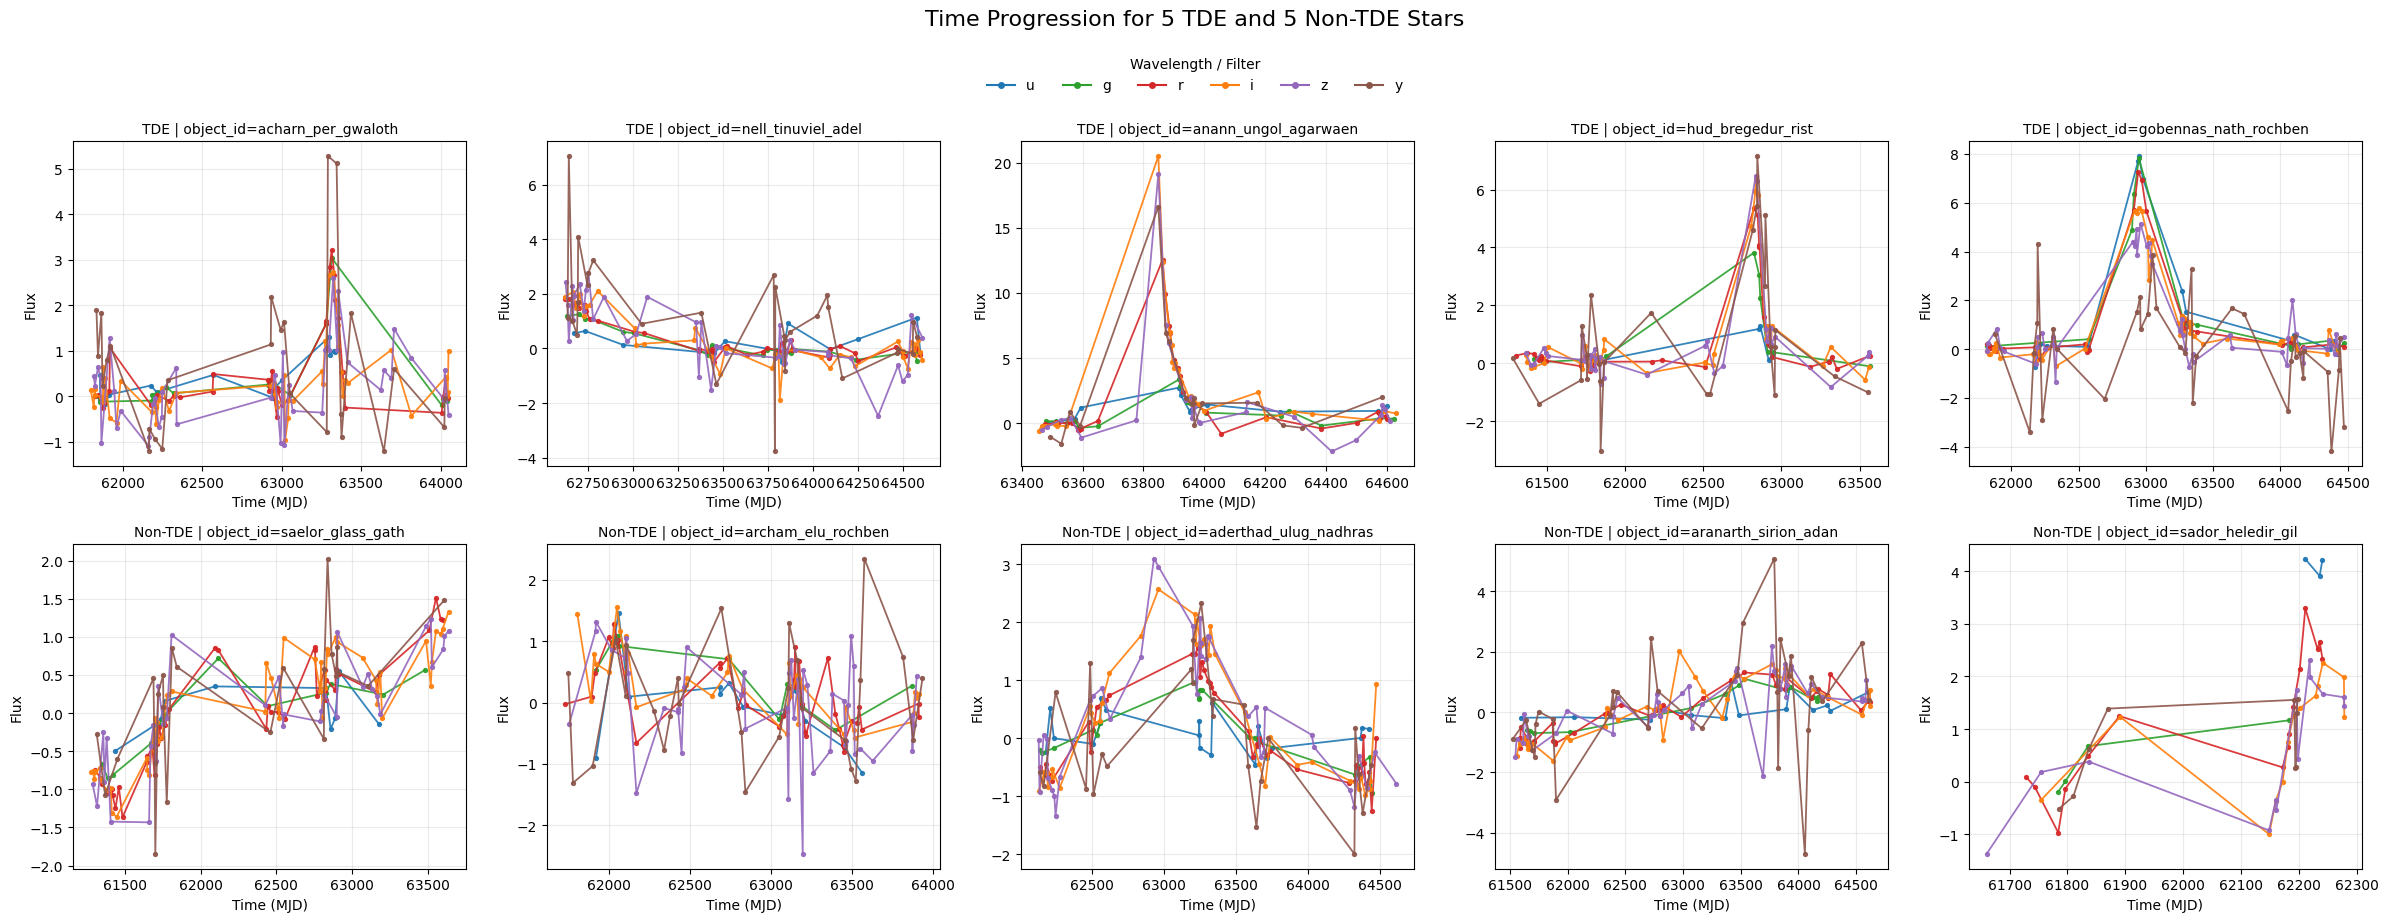

Selected TDE object_ids: ['acharn_per_gwaloth', 'nell_tinuviel_adel', 'anann_ungol_agarwaen', 'hud_bregedur_rist', 'gobennas_nath_rochben']
Selected non-TDE object_ids: ['saelor_glass_gath', 'archam_elu_rochben', 'aderthad_ulug_nadhras', 'aranarth_sirion_adan', 'sador_heledir_gil']


In [ ]:
import matplotlib.pyplot as plt

# --- Build one training lightcurve table across all splits ---
all_train_splits = sorted(train_log["split"].dropna().unique().tolist())
lc_parts = []
for split_name in all_train_splits:
    split_path = root / split_name / "train_full_lightcurves.csv"
    if split_path.exists():
        lc = pd.read_csv(split_path)
        lc["split"] = split_name
        lc_parts.append(lc)

if len(lc_parts) == 0:
    raise FileNotFoundError("No train_full_lightcurves.csv files found under split folders.")

all_lc = pd.concat(lc_parts, ignore_index=True)
ebv_map = train_log[["object_id", "EBV"]].drop_duplicates(subset=["object_id"])
all_lc = all_lc.merge(ebv_map, on="object_id", how="left", validate="many_to_one")
all_lc = apply_mw_deextinction(all_lc)

# Keep only object IDs that actually have lightcurve rows
available_ids = set(all_lc["object_id"].unique())

# target=1 -> TDE, target=0 -> non-TDE
rng = np.random.RandomState(42)

tde_ids = train_log.loc[(train_log["target"] == 1) & (train_log["object_id"].isin(available_ids)), "object_id"].drop_duplicates()
non_tde_ids = train_log.loc[(train_log["target"] == 0) & (train_log["object_id"].isin(available_ids)), "object_id"].drop_duplicates()

if len(tde_ids) < 5 or len(non_tde_ids) < 5:
    raise ValueError(f"Need at least 5 objects per class. Found TDE={len(tde_ids)}, non-TDE={len(non_tde_ids)}")

selected_tde = rng.choice(tde_ids.to_numpy(), size=5, replace=False)
selected_non_tde = rng.choice(non_tde_ids.to_numpy(), size=5, replace=False)
selected_ids = list(selected_tde) + list(selected_non_tde)

selected_lc = all_lc[all_lc["object_id"].isin(selected_ids)].copy()
selected_lc["Time (MJD)"] = pd.to_numeric(selected_lc["Time (MJD)"], errors="coerce")
selected_lc["Flux_deext"] = pd.to_numeric(selected_lc["Flux_deext"], errors="coerce")
selected_lc = selected_lc.dropna(subset=["Time (MJD)", "Flux_deext", "Filter"]).sort_values("Time (MJD)")

# Wavelength/filter colors
filter_colors = {
    "u": "#1f77b4",  # blue
    "g": "#2ca02c",  # green
    "r": "#d62728",  # red
    "i": "#ff7f0e",  # orange
    "z": "#9467bd",  # violet
    "y": "#8c564b",  # brown
}

# Plot 10 stars (5 TDE on first row, 5 non-TDE on second row)
fig, axes = plt.subplots(2, 5, figsize=(24, 9), sharey=False)
axes = axes.flatten()

for i, object_id in enumerate(selected_ids):
    ax = axes[i]
    star_df = selected_lc[selected_lc["object_id"] == object_id]

    for filt in FILTER_ORDER:
        band = star_df[star_df["Filter"] == filt]
        if len(band) == 0:
            continue
        ax.plot(
            band["Time (MJD)"],
            band["Flux_deext"],
            marker="o",
            markersize=2.8,
            linewidth=1.3,
            alpha=0.9,
            color=filter_colors.get(filt, "gray"),
            label=filt,
        )

    cls = "TDE" if i < 5 else "Non-TDE"
    ax.set_title(f"{cls} | object_id={object_id}", fontsize=10)
    ax.set_xlabel("Time (MJD)")
    ax.set_ylabel("De-extincted Flux")
    ax.grid(alpha=0.25)

# One shared legend for wavelength/filter colors
legend_handles = [
    plt.Line2D([0], [0], color=filter_colors[f], marker="o", linestyle="-", linewidth=1.5, markersize=4, label=f)
    for f in FILTER_ORDER
]
fig.legend(
    handles=legend_handles,
    title="Wavelength / Filter",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=len(FILTER_ORDER),
    frameon=False,
)

fig.suptitle("Time Progression for 5 TDE and 5 Non-TDE Stars", fontsize=16, y=1.02)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("Selected TDE object_ids:", selected_tde.tolist())
print("Selected non-TDE object_ids:", selected_non_tde.tolist())